## 11.08节练习参考答案

## 环境准备

In [ ]:
import os, sys
os.environ["TILE_FWK_DEVICE_ID"] = "0"
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
# 本 notebook 位于 answers/ 子目录下，数据缓存在 ../data（与主 notebook 共享），
# 切到章节根目录避免重新慢速下载数据集。
if os.path.isdir("../src"):
    os.chdir("..")

# 固定 PyPTO 编译缓存目录（与 11.11 主 notebook 共用 ../ptile_cache）：
# 内核/Jupyter 重启后无需从零重新编译算子。
# PTO_TILE_LIB_CODE_PATH 目录还必须包含 include/pto（pto-isa 头文件），
# 否则算子编译时报 PTO_ISA_NOT_FOUND；用软链指向 CANN 自带的头文件即可。
os.environ["PTO_TILE_LIB_CODE_PATH"] = os.path.abspath("../ptile_cache")
_pto_lib = os.environ["PTO_TILE_LIB_CODE_PATH"]
os.makedirs(os.path.join(_pto_lib, "include"), exist_ok=True)
_pto_isa_link = os.path.join(_pto_lib, "include", "pto")
if not os.path.exists(_pto_isa_link):
    import glob
    _isa_candidates = glob.glob(os.path.expanduser(
        "~/Ascend/cann-*/aarch64-linux/include/pto"))
    if _isa_candidates:
        os.symlink(os.path.abspath(_isa_candidates[0]), _pto_isa_link)
    else:
        raise RuntimeError("未找到 pto-isa 头文件目录（~/Ascend/cann-*/aarch64-linux/include/pto）")

%matplotlib inline
import pypto
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch_npu
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import math

from src.utils import *
from src.pto_layers import PyPTOLinear, PyPTOReLU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOAvgPool2d

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)，并在此基础上补充了 PyPTO 的实现。

### 练习11.8.1
如果我们设置$\gamma = 1$，实验会发生什么？为什么？

**解答：**

如果我们设置 $\gamma$ 为1，则状态矢量 $s_t$ 的更新函数变为：
$$
s_t \leftarrow s_{t-1}=s_0=0
$$

也就是状态矢量将保持不变为0，则自变量更新函数变为：
$$
x_t \leftarrow x_{t-1}-\frac{\eta}{\sqrt{\epsilon}}\odot g(t)
$$

因此，步长将不会发生改变，将变成确定步长优化。

### 练习11.8.2
旋转优化问题以最小化$f(\mathbf{x}) = 0.1 (x_1 + x_2)^2 + 2 (x_1 - x_2)^2$。收敛会发生什么？

**解答：**

我们首先观察原优化问题：

epoch 20, x1: -0.010599, x2: 0.000000


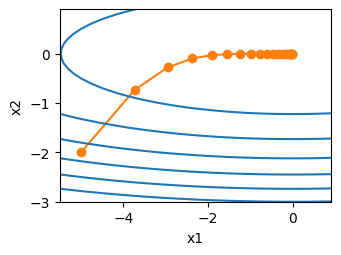

In [3]:
def rmsprop_2d(x1, x2, s1, s2):
    g1, g2, eps = 0.2 * x1, 4 * x2, 1e-6
    s1 = gamma * s1 + (1 - gamma) * g1 ** 2
    s2 = gamma * s2 + (1 - gamma) * g2 ** 2
    x1 -= eta / math.sqrt(s1 + eps) * g1
    x2 -= eta / math.sqrt(s2 + eps) * g2
    return x1, x2, s1, s2

def f_2d(x1, x2):
    return 0.1 * x1 ** 2 + 2 * x2 ** 2

eta, gamma = 0.4, 0.9
show_trace_2d(f_2d, train_2d(rmsprop_2d))

再关注旋转后的优化问题

epoch 20, x1: -0.927150, x2: -0.914018


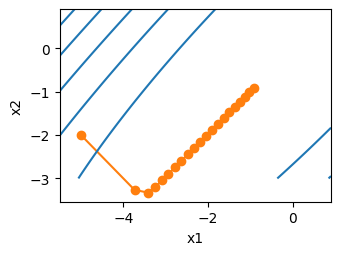

In [ ]:
def rmsprop_2d(x1, x2, s1, s2):
    g1, g2, eps = 4.2 * x1 - 3.8 * x2, 4.2 * x2 - 3.8 * x1, 1e-6
    s1 = gamma * s1 + (1 - gamma) * g1 ** 2
    s2 = gamma * s2 + (1 - gamma) * g2 ** 2
    x1 -= eta / math.sqrt(s1 + eps) * g1
    x2 -= eta / math.sqrt(s2 + eps) * g2
    return x1, x2, s1, s2

def f_2d(x1, x2):
    return 0.1 * (x1 + x2) ** 2 + 2 * (x1 - x2) ** 2

eta, gamma = 0.4, 0.9
show_trace_2d(f_2d, train_2d(rmsprop_2d))

可见，旋转之后的优化问题收敛效果显著变差。

In [5]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def try_gpu(i=0):
    if torch.npu.is_available():
        return torch.device(f"npu:{i}")
    return torch.device("cpu")

# 数据加载直接使用 src.utils 的 load_data_fashion_mnist（drop_last=True）：
# 丢弃不满的尾批，使训练/评估全程只有 bs=256 一种 batch 形状，
# 避免 PyPTO kernel 因尾批形状（96/16）触发新一轮漫长的 JIT 编译。


### 练习11.8.3
试试在真正的机器学习问题上应用RMSProp算法会发生什么，例如在Fashion-MNIST上的训练。试验不同的取值来调整学习率。

**解答：**

In [6]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

def evaluate_accuracy_gpu(net, data_iter, device=None):
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.RMSprop(net.parameters(), lr=lr, alpha=0.9)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

training on npu:0
loss 0.266, train acc 0.899, test acc 0.870
82859.7 examples/sec on npu:0


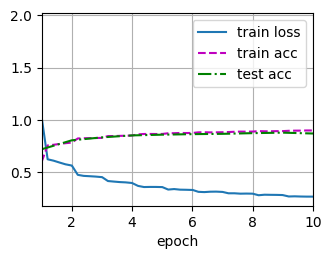

In [8]:
num_epochs = 10
train_ch6(net, train_iter, test_iter, num_epochs, 0.01, try_gpu())

**PyPTO 版**

In [9]:
net = nn.Sequential(
    PyPTOConv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    PyPTOAvgPool2d(kernel_size=2, stride=2),
    PyPTOConv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    PyPTOAvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    PyPTOLinear(16 * 5 * 5, 120), nn.Sigmoid(),
    PyPTOLinear(120, 84), nn.Sigmoid(),
    PyPTOLinear(84, 10))

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

def evaluate_accuracy_gpu(net, data_iter, device=None):
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == PyPTOLinear or type(m) == PyPTOConv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.RMSprop(net.parameters(), lr=lr, alpha=0.9)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

In [10]:
import time

# PyPTO 自定义算子首次调用时需要 JIT 编译，每种新的 batch 形状耗时约 1~2 分钟，
# 期间 notebook 看似“卡住”（无输出），属正常现象，请耐心等待、切勿中断内核。
# 数据加载已启用 drop_last=True，训练/评估全程只有 bs=256 一种 batch 形状，
# 因此只需预热该形状（前向+反向）即可；配合 ../ptile_cache 编译缓存，
device = try_gpu()
net.to(device)
loss_fn = nn.CrossEntropyLoss()
t0 = time.time()
X = torch.randn(256, 1, 28, 28, device=device)
y = torch.randint(0, 10, (256,), device=device)
l = loss_fn(net(X), y)
l.backward()
net.zero_grad()  # 清除预热引入的梯度，避免影响首轮训练
print(f'warm up bs=256: {time.time() - t0:.1f}s', flush=True)

warm up bs=256: 129.7s


training on npu:0
loss 0.291, train acc 0.888, test acc 0.876
21222.5 examples/sec on npu:0


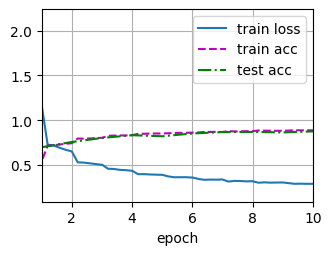

In [11]:
num_epochs = 10
train_ch6(net, train_iter, test_iter, num_epochs, 0.01, try_gpu())

### 练习11.8.4
随着优化的进展，需要调整$\gamma$吗？RMSProp算法对此有多敏感？

**解答：**

$\gamma$（PyTorch 中记为 `alpha`）控制二阶矩的指数滑动平均窗长：$\gamma$ 越大，$s_t$ 对瞬时 $g_t^2$ 的响应越慢，有效步长 $\eta/\sqrt{s_t+\epsilon}$ 衰减越缓。$\gamma$ 对收敛有影响，但不存在“$\gamma=0.99$ 一定很差”的结论——它与学习率耦合：$\gamma$ 大时 $s_t$ 偏小、有效步长偏大，通常需配更小的 $\eta$。实践中 $\gamma$ 一般固定（常用 $0.9$ 或 $0.99$），通过调 $\eta$ 而非随训练动态改 $\gamma$。原解答“初期大 $\gamma$、后期小 $\gamma$”的建议缺乏依据。